# 🚀 06. Grayscale Average (AVG) Training: Custom CNN pada CIFAR-10

Notebook ini melatih model Convolutional Neural Network (CNN) kustom 4-blok pada citra **Grayscale Average (AVG) (1 channel)** berukuran 32x32 piksel dari dataset **CIFAR-10**.
- **Formula Transformasi**: `Gray = (R + G + B) / 3`
- **Input Shape**: `(32, 32, 1)`

### 📋 Partisi Data & Prinsip Anti-Data Leakage:
- **Training Set (90%)**: 45.000 sampel untuk optimasi parameter dan bobot CNN.
- **Validation Set (10% - `validation_split=0.1`)**: 5.000 sampel untuk monitoring callback (`val_loss`, `val_accuracy`, `val_precision`, `val_recall`) dan pemilihan *best model checkpoint*.
- **Test Set Murni**: 10.000 sampel **TIDAK PERNAH DISENTUH** pada tahap training ini; murni diisolasi untuk pengujian akhir pada `09_Grayscale_AVG_Testing_CNN.ipynb` dan `10_Grayscale_AVG_Testing_SVM.ipynb`.
- **Feature Extraction Layer**: `svm_features` (GlobalAveragePooling2D 512-dimensi).
- **Target Artifact**: `cifar10_artifacts/grayscale_avg/cnn_model.keras`


In [1]:
import os
import sys

# Setup CUDA DLL path sebelum import TensorFlow agar cuDNN terdeteksi sempurna
_cuda_bin = r'C:\Users\daffa\anaconda3\envs\CNNgpu\Library\bin'
if os.path.exists(_cuda_bin):
    if _cuda_bin not in os.environ.get('PATH', ''):
        os.environ['PATH'] = _cuda_bin + ';' + os.environ.get('PATH', '')
    if hasattr(os, 'add_dll_directory'):
        try:
            os.add_dll_directory(_cuda_bin)
        except Exception:
            pass

import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Aktifkan GPU memory growth agar hemat VRAM & mencegah error 'DNN library is not found'
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
except Exception:
    pass


ARTIFACT_DIR = 'cifar10_artifacts/grayscale_avg'
os.makedirs(ARTIFACT_DIR, exist_ok=True)
print(f"Artifact directory: {ARTIFACT_DIR}")
print(f"GPU Devices: {tf.config.list_physical_devices('GPU')}")

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout,
    Dense, GlobalAveragePooling2D
)
from tensorflow.keras.regularizers import l2

RANDOM_STATE = 23092026

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def load_cifar10_data(load_train=True, load_test=True):
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
    if load_train:
        X_train = X_train.astype('float32') / 255.0
        y_train = y_train.flatten()
    else:
        X_train, y_train = None, None
    if load_test:
        X_test = X_test.astype('float32') / 255.0
        y_test = y_test.flatten()
    else:
        X_test, y_test = None, None
    return X_train, y_train, X_test, y_test

def transform_grayscale_avg(X):
    return np.mean(X, axis=-1, keepdims=True).astype('float32')

def build_custom_cnn(input_shape=(32, 32, 1), num_classes=10, is_hybrid=False, dense_units=512, dropout_rate=0.25):
    inputs = Input(shape=input_shape, name='input_image')
    weight_decay = 1e-4

    # BLOCK 1: 32x32 -> 16x16 (64 filters)
    x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv1_1')(inputs)
    x = BatchNormalization(name='bn1_1')(x)
    x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv1_2')(x)
    x = BatchNormalization(name='bn1_2')(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool1')(x)
    x = Dropout(dropout_rate * 0.6, name='dropout1')(x)

    # BLOCK 2: 16x16 -> 8x8 (128 filters)
    x = Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv2_1')(x)
    x = BatchNormalization(name='bn2_1')(x)
    x = Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv2_2')(x)
    x = BatchNormalization(name='bn2_2')(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool2')(x)
    x = Dropout(dropout_rate, name='dropout2')(x)

    # BLOCK 3: 8x8 -> 4x4 (256 filters)
    x = Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv3_1')(x)
    x = BatchNormalization(name='bn3_1')(x)
    x = Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv3_2')(x)
    x = BatchNormalization(name='bn3_2')(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool3')(x)
    x = Dropout(dropout_rate * 1.4, name='dropout3')(x)

    # BLOCK 4: 4x4 -> 2x2 (512 filters)
    x = Conv2D(512, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv4_1')(x)
    x = BatchNormalization(name='bn4_1')(x)
    x = Conv2D(512, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='feature_map')(x)
    x = BatchNormalization(name='feature_map_bn')(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool4')(x)
    x = Dropout(dropout_rate * 1.6, name='dropout4')(x)

    # FEATURE EXTRACTION LAYER UNTUK SVM (512 Dimensi)
    svm_features = GlobalAveragePooling2D(name='svm_features')(x)

    # CLASSIFIER HEAD (CNN)
    x = Dense(dense_units, activation='relu', kernel_regularizer=l2(weight_decay), name='cnn_dense')(svm_features)
    x = BatchNormalization(name='cnn_dense_bn')(x)
    x = Dropout(0.50, name='cnn_head_dropout')(x)
    outputs = Dense(num_classes, activation='softmax', name='cnn_softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='custom_cnn')

    METRICS = [
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.10)
    model.compile(loss=loss, optimizer=optimizer, metrics=METRICS)
    return model


Artifact directory: cifar10_artifacts/grayscale_avg
GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📥 1. Memuat Data CIFAR-10, Transformasi Grayscale AVG & Partisi Validation Set (`validation_split=0.1`)
Data training dikonversi ke Grayscale AVG `(32, 32, 1)`, lalu dipartisi dengan rasio 90:10 secara *stratified* menjadi **45.000 Training Data** dan **5.000 Validation Data**.
Data testing (10.000 sampel) diisolasi secara mutlak untuk evaluasi akhir.


Bentuk X_train_feat (AVG): (50000, 32, 32, 1)
=== DISTRIBUSI PARTISI DATASET (ZERO DATA LEAKAGE) ===
1. Training Set   : (45000, 32, 32, 1) | 45000 sampel (90%)
2. Validation Set : (5000, 32, 32, 1)   | 5000 sampel (10% - monitor callback)
3. Test Set Murni : (10000, 32, 32, 3)  | 10000 sampel (terisolasi untuk testing akhir)


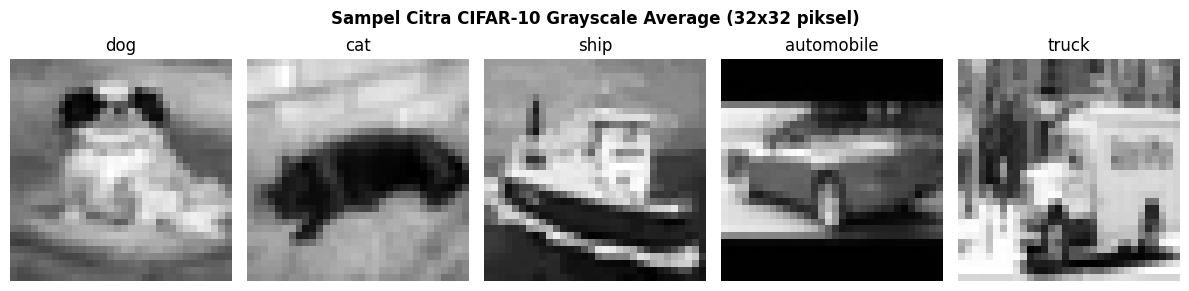

In [2]:
X_train_raw, y_train_raw, X_test, y_test = load_cifar10_data()

# Transformasi citra ke Grayscale Average (AVG) (32, 32, 1)
X_train_feat = transform_grayscale_avg(X_train_raw)
print(f"Bentuk X_train_feat (AVG): {X_train_feat.shape}")

# Partisi Training Set (90% - 45.000 sampel) dan Validation Set (10% - 5.000 sampel)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_feat, y_train_raw,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=y_train_raw
)

y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_val_cat   = tf.keras.utils.to_categorical(y_val, 10)
y_test_cat  = tf.keras.utils.to_categorical(y_test, 10)

print("=== DISTRIBUSI PARTISI DATASET (ZERO DATA LEAKAGE) ===")
print(f"1. Training Set   : {X_train.shape} | {len(X_train)} sampel (90%)")
print(f"2. Validation Set : {X_val.shape}   | {len(X_val)} sampel (10% - monitor callback)")
print(f"3. Test Set Murni : {X_test.shape}  | {len(X_test)} sampel (terisolasi untuk testing akhir)")

# Visualisasi sampel citra Grayscale AVG
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(X_train[i].squeeze(), cmap='gray')
    axes[i].set_title(f"{CLASS_NAMES[y_train[i]]}")
    axes[i].axis('off')
plt.suptitle('Sampel Citra CIFAR-10 Grayscale Average (32x32 piksel)', fontweight='bold')
plt.tight_layout()
plt.show()


## 🏗️ 2. Membangun Model CNN Kustom Grayscale (1 Channel)
Arsitektur 4-blok dengan layer ekstraksi `svm_features` (GlobalAveragePooling2D 512-dimensi) dan input shape `(32, 32, 1)`.


In [3]:
cnn_model = build_custom_cnn(input_shape=(32, 32, 1), num_classes=10, is_hybrid=False)
cnn_model.summary()


Model: "custom_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 32, 32, 1)]       0         
                                                                 
 conv1_1 (Conv2D)            (None, 32, 32, 64)        640       
                                                                 
 bn1_1 (BatchNormalization)  (None, 32, 32, 64)        256       
                                                                 
 conv1_2 (Conv2D)            (None, 32, 32, 64)        36928     
                                                                 
 bn1_2 (BatchNormalization)  (None, 32, 32, 64)        256       
                                                                 
 pool1 (MaxPooling2D)        (None, 16, 16, 64)        0         
                                                                 
 dropout1 (Dropout)          (None, 16, 16, 64)        0

## ⚙️ 3. Training CNN dengan Data Augmentation & Callbacks Lengkap
Callbacks aktif:
1. `ReduceLROnPlateau`: Memantau `val_loss` untuk mereduksi learning rate saat konvergensi melambat.
2. `EarlyStopping`: Memantau `val_accuracy` untuk menghentikan training saat tidak ada peningkatan dan mengembalikan bobot terbaik.
3. `ModelCheckpoint`: Memantau `val_accuracy` dengan `save_best_only=True` untuk menyimpan model CNN terbaik ke `cnn_model.keras`.


In [4]:
cnn_model_path = os.path.join(ARTIFACT_DIR, 'cnn_model.keras')

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_accuracy', mode='max', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(cnn_model_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
]

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    zoom_range=0.10,
    fill_mode='reflect'
)

BATCH_SIZE = 128
EPOCHS = 30
train_flow = datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE, shuffle=True, seed=RANDOM_STATE)

print("Memulai pelatihan CNN Grayscale Average (AVG) dengan monitoring Validation Set...")
history = cnn_model.fit(
    train_flow,
    epochs=EPOCHS,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val_cat),
    callbacks=callbacks,
    verbose=1
)

# Memastikan bobot model terbaik tersimpan ke disk
cnn_model.save(cnn_model_path)
print(f"[BERHASIL] Model CNN AVG terbaik disimpan ke: {cnn_model_path}")


Memulai pelatihan CNN Grayscale Average (AVG) dengan monitoring Validation Set...
Epoch 1/30
351/351 [==============================] - ETA: 0s - loss: 2.3672 - accuracy: 0.3510 - precision: 0.4717 - recall: 0.1703
Epoch 1: val_accuracy improved from -inf to 0.13620, saving model to cifar10_artifacts/grayscale_avg\cnn_model.keras
351/351 [==============================] - 44s 92ms/step - loss: 2.3672 - accuracy: 0.3510 - precision: 0.4717 - recall: 0.1703 - val_loss: 3.9081 - val_accuracy: 0.1362 - val_precision: 0.3106 - val_recall: 0.0464 - lr: 0.0010
Epoch 2/30
351/351 [==============================] - ETA: 0s - loss: 1.7622 - accuracy: 0.5552 - precision: 0.7371 - recall: 0.3683
Epoch 2: val_accuracy improved from 0.13620 to 0.66660, saving model to cifar10_artifacts/grayscale_avg\cnn_model.keras
351/351 [==============================] - 29s 83ms/step - loss: 1.7622 - accuracy: 0.5552 - precision: 0.7371 - recall: 0.3683 - val_loss: 1.5185 - val_accuracy: 0.6666 - val_precision: 

## 📈 4. Visualisasi Kurva Pelatihan (Training vs Validation Metrics)
Menampilkan kurva Loss, Accuracy, Precision, dan Recall antara Training vs Validation.


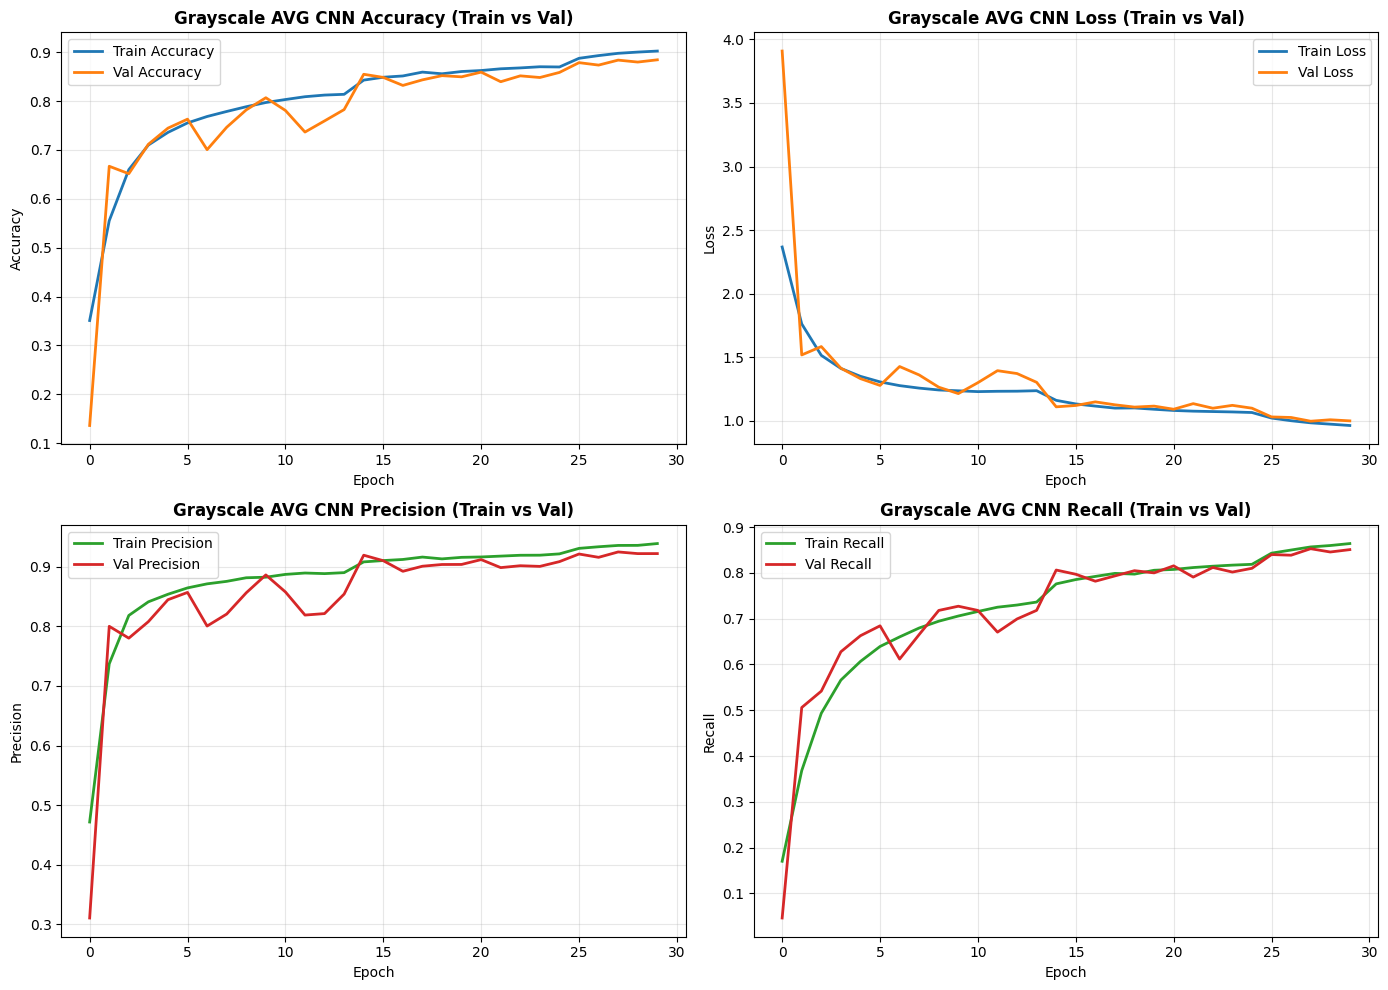

Kurva pelatihan tersimpan ke: cifar10_artifacts/grayscale_avg\learning_curves.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy Curve
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', lw=2, color='#1f77b4')
if 'val_accuracy' in history.history:
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', lw=2, color='#ff7f0e')
axes[0, 0].set_title('Grayscale AVG CNN Accuracy (Train vs Val)', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Loss Curve
axes[0, 1].plot(history.history['loss'], label='Train Loss', lw=2, color='#1f77b4')
if 'val_loss' in history.history:
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', lw=2, color='#ff7f0e')
axes[0, 1].set_title('Grayscale AVG CNN Loss (Train vs Val)', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3. Precision Curve
axes[1, 0].plot(history.history.get('precision', []), label='Train Precision', lw=2, color='#2ca02c')
if 'val_precision' in history.history:
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision', lw=2, color='#d62728')
axes[1, 0].set_title('Grayscale AVG CNN Precision (Train vs Val)', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. Recall Curve
axes[1, 1].plot(history.history.get('recall', []), label='Train Recall', lw=2, color='#2ca02c')
if 'val_recall' in history.history:
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', lw=2, color='#d62728')
axes[1, 1].set_title('Grayscale AVG CNN Recall (Train vs Val)', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plot_path = os.path.join(ARTIFACT_DIR, 'learning_curves.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Kurva pelatihan tersimpan ke: {plot_path}")
